In [9]:
# ============ #
# 1. LIBRERÍAS #
# ============ #

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_percentage_error


In [10]:
# =================== #
# 2. LECTURA DE RUTAS #
# =================== #

mainpath = os.path.join(os.getcwd(), "..", "..", "data", "raw")
filename = "job_salary_prediction_dataset.csv"
fullpath = os.path.join(mainpath, filename)


In [11]:
# ================= #
# 3. CARGA DE DATOS #
# ================= #

df = pd.read_csv(fullpath, sep=",")
pd.set_option('display.max_columns', None)


In [12]:
# ============================== #
# 4. IDENTIFICACIÓN DE VARIABLES #
# ============================== #

def variables(df = df):
    float_cols = df.select_dtypes(include='float64').columns.tolist()
    int_cols = df.select_dtypes(include='int64').columns.tolist()
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    target = 'salary'
    features = [col for col in float_cols + int_cols if col != target]
    return features, target, cat_cols

features, target, cat_cols = variables()


In [13]:
# ================ #
# 5. PREPROCESADOR #
# ================ #

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), features)
])


In [14]:
# =============================== #
# VISUALIZAR EL PRE-PROCESAMIENTO #
# =============================== #

preprocessor


ColumnTransformer(transformers=[('cat',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 ['job_title', 'education_level', 'industry',
                                  'company_size', 'location', 'remote_work']),
                                ('num', StandardScaler(),
                                 ['experience_years', 'skills_count',
                                  'certifications'])])

In [15]:
# ========================= #
# 6. PARTICIÓN TRAIN / TEST #
# ========================= #

X = df[features + cat_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [16]:
# ======================== #
# 7. MODELO ISOTÓNICA      #
# ======================== #

from sklearn.preprocessing import FunctionTransformer

to_dense = FunctionTransformer(lambda x: x.toarray() if hasattr(x, 'toarray') else x)
flatten = FunctionTransformer(lambda x: x.mean(axis=1).reshape(-1, 1) if x.ndim > 1 else x)

model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('to_dense', to_dense),
    ('flatten', flatten),
    ('regressor', IsotonicRegression(out_of_bounds='clip'))
])

model.fit(X_train, y_train.values)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['job_title',
                                                   'education_level',
                                                   'industry', 'company_size',
                                                   'location', 'remote_work']),
                                                 ('num', StandardScaler(),
                                                  ['experience_years',
                                                   'skills_count',
                                                   'certifications'])])),
                ('to_dense',
                 FunctionTransformer(func=<function <lambda> at 0x712e43121760>)),
                ('flatten',
                 FunctionTransformer(func=<function <lambda> at 0x712e431214e0>)),
                ('regressor', IsotonicRegression(out_of_bounds='clip'))])

In [17]:
# ============== #
# 8. EVALUACIÓN  #
# ============== #

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)
print("MAPE(%):", mape * 100)
print("R2:", r2)


MAE: 28549.497668557888
RMSE: 36057.40609375728
MAPE: 0.2166342111270704
MAPE(%): 21.66342111270704
R2: 0.06704135387655052


In [18]:
# ======================================== #
# 8.1. DATAFRAME CON RESULTADOS Y ERRORES  #
# ======================================== #

X_test_df = pd.DataFrame(X_test).reset_index(drop=True)
y_test_df = pd.Series(y_test).reset_index(drop=True)
y_pred_df = pd.Series(y_pred)

df_resultados = X_test_df.copy()
df_resultados["y_real"] = y_test_df
df_resultados["y_pred"] = y_pred_df
df_resultados["error"] = df_resultados["y_real"] - df_resultados["y_pred"]
df_resultados["abs_error"] = df_resultados["error"].abs()

df_resultados.sample(20)


,experience_years,skills_count,certifications,job_title,education_level,industry,company_size,location,remote_work,y_real,y_pred,error,abs_error
26007,7,8,4,Machine Learning Engineer,Diploma,Media,Medium,Singapore,Hybrid,136498,146104.153816,-9606.153816,9606.153816
9820,0,15,3,Cybersecurity Analyst,Bachelor,Retail,Startup,Remote,No,106516,142507.968448,-35991.968448,35991.968448
66288,5,9,5,Backend Developer,PhD,Technology,Medium,Germany,Yes,149579,153120.404610,-3541.404610,3541.404610
45007,18,18,1,Software Engineer,Bachelor,Healthcare,Small,UK,No,163212,156185.508564,7026.491436,7026.491436
37731,5,7,4,Software Engineer,Diploma,Telecom,Enterprise,India,Yes,88333,142507.968448,-54174.968448,54174.968448
38625,0,7,1,Frontend Developer,Bachelor,Retail,Large,USA,No,133197,129878.684042,3318.315958,3318.315958
10952,11,12,4,Data Scientist,Diploma,Finance,Large,USA,Hybrid,189142,153120.404610,36021.595390,36021.595390
17212,18,10,1,AI Engineer,Master,Finance,Large,UK,No,228111,146933.327486,81177.672514,81177.672514
55638,7,9,5,Business Analyst,High School,Technology,Startup,Sweden,No,83375,155635.751248,-72260.751248,72260.751248
8898,10,5,3,DevOps Engineer,Diploma,Manufacturing,Enterprise,India,Hybrid,106231,137283.011650,-31052.011650,31052.011650


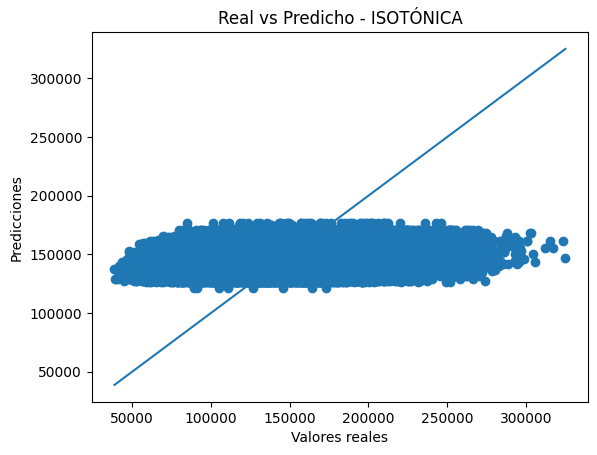

In [19]:
# ====================== #
# 8.2. REAL VS PREDICHO  #
# ====================== #

plt.scatter(df_resultados["y_real"], df_resultados["y_pred"])
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Real vs Predicho - ISOTÓNICA")
plt.plot(
    [df_resultados["y_real"].min(), df_resultados["y_real"].max()],
    [df_resultados["y_real"].min(), df_resultados["y_real"].max()]
)
plt.show()


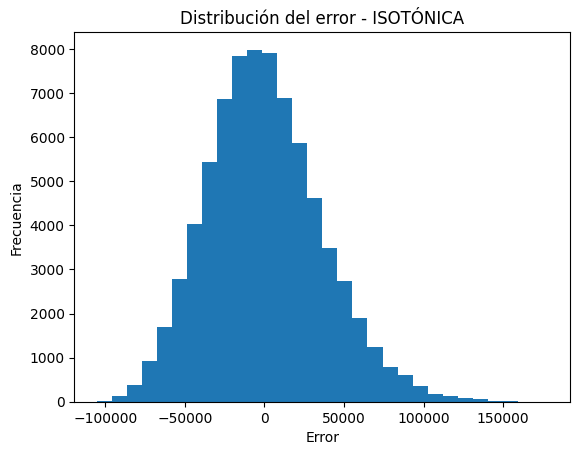

In [20]:
# ============================= #
# 8.3. DISTRIBUCIÓN DE ERRORES  #
# ============================= #

plt.hist(df_resultados["error"], bins=30)
plt.title("Distribución del error - ISOTÓNICA")
plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.show()
